# IKEA Product Catalog Analysis

This notebook analyzes an IKEA product catalog dataset found on **Kaggle**.

The dataset contains product-level information such as product name, product type, category, subcategory, rating, number of reviews, online availability, price, currency, discount, sale tag, and country.

The goal is to explore how IKEA products differ across European markets in terms of price, online availability, categories, ratings, reviews, promotional tags, and country-level evaluation patterns.

## Dataset structure

The original dataset contains **401,046 rows** and **18 columns**.

Each row represents an IKEA product in a specific country. The same `product_id` can therefore appear multiple times, once for each country where the product is available.

Main columns used in this notebook:

- `product_id`, `product_name`, `product_type`
- `main_category`, `sub_category`
- `product_rating`, `product_rating_count`
- `badge`, `online_sellable`
- `price`, `currency`, `discount`, `sale_tag`
- `country`

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from plotly.subplots import make_subplots
from matplotlib.patches import Patch
from deep_translator import GoogleTranslator
import time




sns.set_theme(style='whitegrid')

## Reusable functions and constants

In [2]:
EUROPEAN_COUNTRIES = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Netherlands', 'Norway', 'Poland',
    'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain',
    'Sweden', 'Switzerland', 'United Kingdom'
]

EUR_RATES = {
    'EUR': 1.00, 'GBP': 1.17, 'CHF': 1.05, 'SEK': 0.087, 'NOK': 0.086,
    'DKK': 0.134, 'PLN': 0.23, 'CZK': 0.040, 'HUF': 0.0026,
    'RON': 0.20, 'RSD': 0.0085
}

PRICE_BINS = [0, 10, 25, 50, 100, 250, float('inf')]
PRICE_LABELS = ['< €10', '€10–25', '€25–50', '€50–100', '€100–250', '€250+']

def to_numeric(df, cols):
    df = df.copy()
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def as_bool(s):
    return s.astype(str).str.strip().str.lower().map({
        'true': True, 'false': False, '1': True, '0': False, 'yes': True, 'no': False
    })

def add_price_eur(df):
    df = to_numeric(df, ['price'])
    return df.assign(price_eur=df['price'] * df['currency'].map(EUR_RATES))

def rated_products(df, min_reviews=10, extra_cols=None):
    cols = ['product_rating', 'product_rating_count']
    df = to_numeric(df, cols)
    keep = cols + (extra_cols or [])
    return df.dropna(subset=keep).query('product_rating_count >= @min_reviews').copy()

def top_values(df, col, n=10):
    return df[col].value_counts().head(n).index

def add_bar_labels(ax, values, fmt='{:.0f}', offset=None, fontsize=10):
    offset = max(values) * 0.01 if offset is None and len(values) else 0
    for i, value in enumerate(values):
        ax.text(i, value + offset, fmt.format(value), ha='center', va='bottom', fontsize=fontsize)

def box_stats(df, group_col, value_col, order):
    rows = []
    for group in order:
        values = df.loc[df[group_col] == group, value_col].dropna()
        q1, med, q3 = values.quantile(.25), values.median(), values.quantile(.75)
        iqr = q3 - q1
        rows.append({
            'group': group, 'q1': q1, 'median': med, 'q3': q3,
            'min_whisker': values[values >= q1 - 1.5 * iqr].min(),
            'max_whisker': values[values <= q3 + 1.5 * iqr].max(),
            'real_min': values.min(), 'real_max': values.max()
        })
    return pd.DataFrame(rows)

def country_price_band(value):
    if value < 95:
        return 'Below median'
    if value <= 105:
        return 'Aligned'
    return 'Above median'

def box_stats(df, group_col, value_col, group_order):
    rows = []
    for group in group_order:
        v = df.loc[df[group_col] == group, value_col].dropna()
        q1, med, q3 = v.quantile(.25), v.median(), v.quantile(.75)
        iqr = q3 - q1
        rows.append({
            'group': group,
            'min_whisker': v[v >= q1 - 1.5 * iqr].min(),
            'q1': q1,
            'median_value': med,
            'q3': q3,
            'max_whisker': v[v <= q3 + 1.5 * iqr].max(),
            'real_min': v.min(),
            'real_max': v.max()
        })
    return pd.DataFrame(rows)


def add_manual_box(fig, stats, col, colors, positions, decimals=2, showlegend=True):
    fmt = f'.{decimals}f'
    for _, r in stats.iterrows():
        g = r['group']
        fig.add_trace(
            go.Box(
                x=[positions[g]],
                q1=[r['q1']],
                median=[r['median_value']],
                q3=[r['q3']],
                lowerfence=[r['min_whisker']],
                upperfence=[r['max_whisker']],
                name=g,
                boxpoints=False,
                width=0.55,
                marker_color=colors[g],
                showlegend=showlegend,
                customdata=[[
                    g, r['min_whisker'], r['q1'], r['median_value'],
                    r['q3'], r['max_whisker'], r['real_min'], r['real_max']
                ]],
                hovertemplate=(
                    '<b>%{customdata[0]}</b><br>'
                    f'Whisker min: %{{customdata[1]:{fmt}}}<br>'
                    f'Q1: %{{customdata[2]:{fmt}}}<br>'
                    f'Median: %{{customdata[3]:{fmt}}}<br>'
                    f'Q3: %{{customdata[4]:{fmt}}}<br>'
                    f'Whisker max: %{{customdata[5]:{fmt}}}<br><br>'
                    f'Real min: %{{customdata[6]:{fmt}}}<br>'
                    f'Real max: %{{customdata[7]:{fmt}}}'
                    '<extra></extra>'
                )
            ),
            row=1,
            col=col
        )

def translate_column_values(df, column, target_lang='en', sleep_time=0.2):
    translator = GoogleTranslator(source='auto', target=target_lang)

    unique_values = (
        df[column]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

    translation_map = {}

    for value in unique_values:
        try:
            translation_map[value] = translator.translate(value)
            time.sleep(sleep_time)
        except:
            translation_map[value] = value

    translated_column = (
        df[column]
        .astype(str)
        .str.strip()
        .map(translation_map)
        .str.lower()
        .str.replace('&', 'and', regex=False)
        .str.replace('organisation', 'organization', regex=False)
        .str.title()
    )

    return translated_column, translation_map

## Data loading and geographic filter

In [3]:
df = pd.read_csv('IKEA_product_catalog.csv')
df_europe = df[df['country'].isin(EUROPEAN_COUNTRIES)].copy()

print('Original dataset:', df.shape)
print('European dataset:', df_europe.shape)
print('European countries:', sorted(df_europe['country'].dropna().unique()))
display(df_europe.head())

Original dataset: (401046, 18)
European dataset: (200346, 18)
European countries: ['Austria', 'Belgium', 'Croatia', 'Denmark', 'Finland', 'France', 'Germany', 'Hungary', 'Ireland', 'Italy', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland']


,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.3,6.0,none,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.99,EUR,none,NONE,Austria
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.99,EUR,none,NONE,Belgium
7,10018194-Croatia,10018194,ORDNING,Ocjeđivač posuđa,50x27x36 cm,Ocijedivač posuđa ORDNING od nehrđajućeg čelik...,sve-za-kuhanje,dodaci-za-pranje-posuda,3.7,543.0,none,True,https://www.ikea.com/hr/hr/p/ordning-ocjedivac...,19.99,EUR,none,NONE,Croatia
9,10018194-Denmark,10018194,ORDNING,Opvaskestativ,50x27x36 cm,Et opvaskestativ i rustfrit stål ORDNING med s...,kokkenudstyr-og-borddaekning,tilbehor-til-opvask,3.7,543.0,none,True,https://www.ikea.com/dk/da/p/ordning-opvaskest...,199.00,DKK,none,NONE,Denmark
11,10018194-Finland,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/fi/en/p/ordning-dish-drai...,29.99,EUR,none,NONE,Finland


## Analysis 1: Do IKEA prices change across countries?

This analysis compares IKEA prices across European countries.

Because the catalog contains products sold with different currencies, prices are first converted to euros using approximate exchange rates. To make the comparison fairer, the analysis does not compare simple average prices by country. Instead, each product price is compared with the European median price of the same product.

The resulting price index is interpreted as follows:

- `100` = the product costs approximately the same as its European median price;
- `> 100` = the product is more expensive than its European median;
- `< 100` = the product is cheaper than its European median.

The final plot shows the distribution of this price index by country using a boxplot.

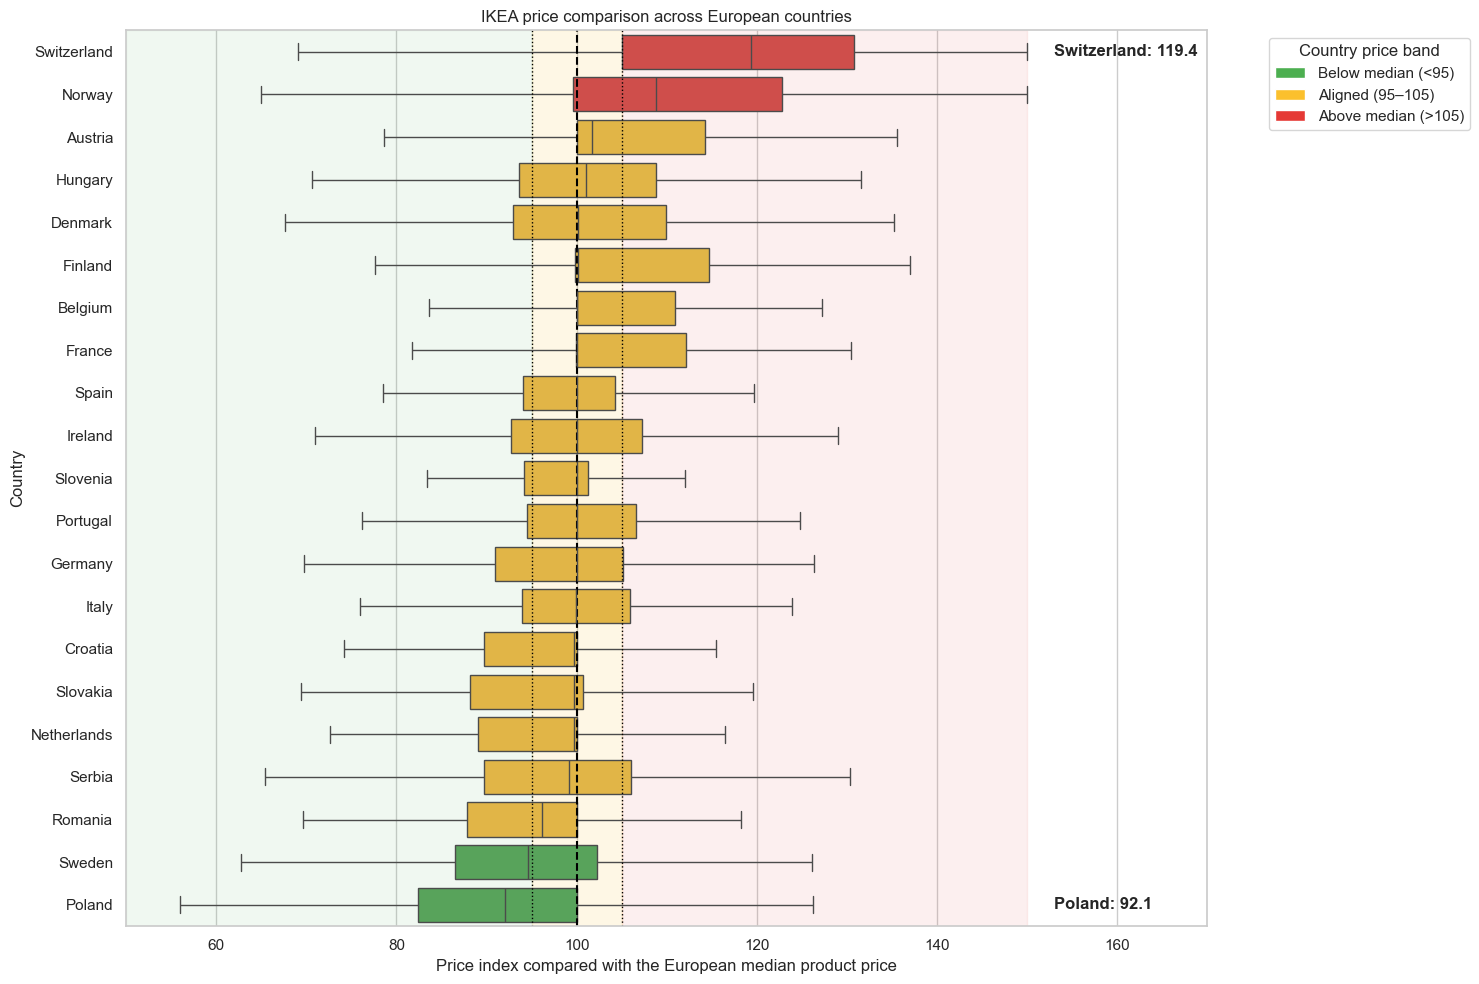

In [4]:
price_country = add_price_eur(df_europe).dropna(subset=['price_eur', 'country', 'product_id'])
valid_products = price_country.groupby('product_id')['country'].nunique().loc[lambda s: s >= 5].index
price_country = price_country[price_country['product_id'].isin(valid_products)].copy()
price_country['median_product_price_eur'] = price_country.groupby('product_id')['price_eur'].transform('median')
price_country['price_index'] = price_country['price_eur'] / price_country['median_product_price_eur'] * 100

plot_df = price_country.query('50 <= price_index <= 150').copy()
country_medians = plot_df.groupby('country')['price_index'].median().sort_values(ascending=False)
country_order = country_medians.index
band_colors = {'Below median': '#4CAF50', 'Aligned': '#FBC02D', 'Above median': '#E53935'}
country_palette = {c: band_colors[country_price_band(country_medians[c])] for c in country_order}

fig, ax = plt.subplots(figsize=(15, 10))
for start, end, color, alpha in [(50, 95, '#4CAF50', .08), (95, 105, '#FBC02D', .12), (105, 150, '#E53935', .08)]:
    ax.axvspan(start, end, alpha=alpha, color=color)

sns.boxplot(data=plot_df, x='price_index', y='country', order=country_order,
            hue='country', palette=country_palette, legend=False, showfliers=False, ax=ax)

for x, style, lw in [(95, ':', 1), (100, '--', 1.5), (105, ':', 1)]:
    ax.axvline(x, linestyle=style, color='black', linewidth=lw)

for country in [country_medians.idxmax(), country_medians.idxmin()]:
    ax.text(153, list(country_order).index(country), f'{country}: {country_medians[country]:.1f}',
            va='center', ha='left', fontsize=12, fontweight='bold')

ax.set(title='IKEA price comparison across European countries',
       xlabel='Price index compared with the European median product price',
       ylabel='Country', xlim=(50, 170))
ax.tick_params(axis='both', labelsize=11)
ax.legend(handles=[
    Patch(facecolor='#4CAF50', label='Below median (<95)'),
    Patch(facecolor='#FBC02D', label='Aligned (95–105)'),
    Patch(facecolor='#E53935', label='Above median (>105)')
], title='Country price band', bbox_to_anchor=(1.05, 1), loc='upper left',
   fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

## Analysis 2: How much of the IKEA catalog is sellable online across countries?

This analysis studies the online availability of IKEA products across European countries.

For each country, two values are calculated:

- total number of products in the catalog;
- percentage of products that are sellable online.

The plot uses two subplots with the same x-axis, making it possible to compare catalog size and online availability for each country.

In [5]:
# Filtra solo i prodotti NON disponibili online
not_online = online[online['online_sellable'] == False].copy()

# Traduce / normalizza le categorie principali
not_online['main_category_clean'], main_category_map = translate_column_values(
    not_online,
    'main_category'
)

# Conta i prodotti non online per paese e categoria tradotta
country_category_not_online = (
    not_online
    .groupby(['country', 'main_category_clean'], as_index=False)
    .agg(not_online_products=('product_id', 'count'))
)

# Trasforma i dati in formato pivot per lo stacked bar chart
country_category_pivot = (
    country_category_not_online
    .pivot(
        index='country',
        columns='main_category_clean',
        values='not_online_products'
    )
    .fillna(0)
)

# Ordina le nazioni per totale di prodotti non disponibili online
country_category_pivot['total'] = country_category_pivot.sum(axis=1)
country_category_pivot = country_category_pivot.sort_values(
    'total',
    ascending=False
)

# Rimuove la colonna total prima del grafico
country_category_pivot_plot = country_category_pivot.drop(columns='total')

# Crea stacked bar chart
ax = country_category_pivot_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(24, 10),
    colormap='Greens'
)

ax.set_title(
    'Products not available online by country and main category',
    fontsize=18,
    fontweight='bold'
)

ax.set_xlabel('Country')
ax.set_ylabel('Number of products not available online')

ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='both', labelsize=11)

ax.legend(
    title='Main category',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

NameError: name 'online' is not defined

## Analysis 3: Which IKEA categories are most present across European countries?

This analysis studies the distribution of the main IKEA categories across European countries.

The goal is to understand whether the most common categories are similarly distributed across countries or whether some markets have a stronger presence of specific categories.

To keep the heatmap readable, only the 10 most frequent main categories in the European dataset are considered. The color represents the number of products for each country-category combination.

In [ ]:
cat_country = df_europe.dropna(subset=['country', 'main_category', 'product_id']).copy()
cat_country = cat_country[cat_country['main_category'].isin(top_values(cat_country, 'main_category', 10))]

pivot = cat_country.pivot_table(index='main_category', columns='country', values='product_id',
                                aggfunc='count', fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index,
                  pivot.sum(axis=0).sort_values(ascending=False).index]

plt.figure(figsize=(18, 8))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=.5, linecolor='white', annot=True, fmt='d')
plt.title('Distribution of the main IKEA categories across European countries',
          fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=13)
plt.ylabel('Main category', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Analysis 4: Are TOP_SELLER products rated better than other products?

This analysis compares products marked as `TOP_SELLER` with all other IKEA products.

The goal is to check whether products highlighted by the catalog also have better ratings and more reviews. To make the comparison more reliable, only products with at least 10 reviews are considered.

The interactive plot contains two boxplots:

- rating distribution;
- review-count distribution.

The boxplot statistics follow the standard IQR rule used by seaborn-style boxplots.

In [ ]:
top_seller_df = df_europe.copy()
top_seller_df[['product_rating', 'product_rating_count']] = top_seller_df[
    ['product_rating', 'product_rating_count']
].apply(pd.to_numeric, errors='coerce')

top_seller_df = top_seller_df.dropna(
    subset=['product_rating', 'product_rating_count']
)
top_seller_df = top_seller_df[top_seller_df['product_rating_count'] >= 10].copy()
top_seller_df['badge_group'] = np.where(
    top_seller_df['badge'].eq('TOP_SELLER'),
    'TOP_SELLER',
    'Other'
)

groups = ['Other', 'TOP_SELLER']
colors = {'Other': '#4C78A8', 'TOP_SELLER': '#F58518'}
positions = {'Other': 0, 'TOP_SELLER': 1}

rating_stats = box_stats(top_seller_df, 'badge_group', 'product_rating', groups)
review_stats = box_stats(top_seller_df, 'badge_group', 'product_rating_count', groups)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=['Rating distribution', 'Review count distribution']
)

add_manual_box(fig, rating_stats, col=1, colors=colors, positions=positions, decimals=2)
add_manual_box(fig, review_stats, col=2, colors=colors, positions=positions, decimals=0, showlegend=False)

for c in [1, 2]:
    fig.update_xaxes(
        title_text='Product group',
        tickmode='array',
        tickvals=[0, 1],
        ticktext=groups,
        range=[-0.7, 1.7],
        row=1,
        col=c
    )

fig.update_yaxes(title_text='Average rating', range=[3.5, 5.1], row=1, col=1)
fig.update_yaxes(
    title_text='Number of reviews',
    type='log',
    tickmode='array',
    tickvals=[10, 100, 1000, 10000],
    ticktext=['10', '100', '1k', '10k'],
    minor=dict(ticks='', showgrid=False),
    row=1,
    col=2
)

fig.update_layout(
    title='Interactive comparison between TOP_SELLER and other products',
    width=1200,
    height=600,
    template='plotly_white',
    boxmode='overlay'
)

fig.show()

## Analysis 5: How does the rating of the same product change across European countries?

This analysis focuses on one IKEA product instead of considering the whole catalog at once.

This is useful because it compares the same item across European countries, avoiding a mix of very different products. The selected product is the one available in the highest number of European countries, considering only observations with at least 10 reviews.

The plot contains two subplots:

- average rating of the selected product by country;
- number of reviews received by the selected product by country.

In [ ]:
single = rated_products(df_europe.copy(), 10, ['product_id', 'product_name', 'country'])
summary = (single.groupby(['product_id', 'product_name'])
           .agg(n_countries=('country', 'nunique'), total_reviews=('product_rating_count', 'sum'))
           .sort_values(['n_countries', 'total_reviews'], ascending=False).reset_index())

selected_id, selected_name = summary.loc[0, ['product_id', 'product_name']]
single = single[single['product_id'].eq(selected_id)].sort_values('product_rating', ascending=False)

print('Selected product:', selected_name)
print('Product ID:', selected_id)
print('Number of countries:', single['country'].nunique())
print('Total reviews:', int(single['product_rating_count'].sum()))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
sns.barplot(data=single, x='country', y='product_rating', ax=axes[0])
sns.barplot(data=single, x='country', y='product_rating_count', ax=axes[1])

axes[0].set(title=f'Rating of "{selected_name}" across countries', xlabel='', ylabel='Average rating', ylim=(3.5, 5.1))
axes[1].set(title=f'Reviews of "{selected_name}" across countries', xlabel='Country', ylabel='Number of reviews')
add_bar_labels(axes[0], single['product_rating'], fmt='{:.2f}', offset=.03)
add_bar_labels(axes[1], single['product_rating_count'], fmt='{:.0f}')
axes[1].set_ylim(0, single['product_rating_count'].max() * 1.15)
axes[1].tick_params(axis='x', rotation=35)
for ax in axes:
    ax.tick_params(axis='both', labelsize=11)

plt.suptitle(f'International comparison of "{selected_name}"', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Analysis 6: Are IKEA promotional tags associated with different prices or ratings?

This analysis studies IKEA products by `sale_tag`, the commercial label associated with a product.

The goal is to understand whether products with different promotional tags show differences in median price and average rating.

To keep the comparison readable, only the most frequent promotional tags in the European dataset are considered. The plot contains three subplots:

- number of products by tag;
- median price in euros;
- average rating.

In [ ]:
sale = add_price_eur(df_europe.copy())
sale = rated_products(sale, 10, ['sale_tag', 'price_eur'])
sale['sale_tag'] = sale['sale_tag'].astype(str).str.strip()
sale = sale[sale['sale_tag'].ne('') & sale['sale_tag'].str.lower().ne('nan')]
sale = sale[sale['sale_tag'].isin(top_values(sale, 'sale_tag', 6))]

sale_summary = (sale.groupby('sale_tag')
    .agg(product_count=('product_id', 'count'), median_price_eur=('price_eur', 'median'),
         mean_rating=('product_rating', 'mean'))
    .sort_values('product_count', ascending=False).reset_index())

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
plots = [('product_count', 'Number of products by promotional tag', 'Number of products', '{:.0f}'),
         ('median_price_eur', 'Median price by promotional tag', 'Median price (€)', '€{:.2f}'),
         ('mean_rating', 'Average rating by promotional tag', 'Average rating', '{:.2f}')]

for ax, (col, title, ylabel, fmt) in zip(axes, plots):
    sns.barplot(data=sale_summary, x='sale_tag', y=col, ax=ax)
    ax.set(title=title, xlabel='', ylabel=ylabel)
    add_bar_labels(ax, sale_summary[col], fmt=fmt)
    if col != 'mean_rating':
        ax.set_ylim(0, sale_summary[col].max() * 1.15)
axes[2].set(xlabel='Promotional tag', ylim=(3.5, 5.1))
axes[2].tick_params(axis='x', rotation=25)
for ax in axes:
    ax.tick_params(axis='both', labelsize=10)

plt.suptitle('Comparison of IKEA promotional tags in European countries',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Analysis 7: Are some IKEA categories rated better in certain countries?

This analysis compares the average rating of the main IKEA categories across European countries.

The goal is to understand whether some categories receive better ratings in specific countries or whether ratings remain fairly similar across markets.

To avoid an overcrowded heatmap, only the 10 most frequent categories are considered. Products are filtered to at least 10 reviews so that average ratings are more reliable.

In [ ]:
rating_heatmap = rated_products(df_europe.copy(), 10, ['country', 'main_category'])
rating_heatmap = rating_heatmap[rating_heatmap['main_category'].isin(top_values(rating_heatmap, 'main_category', 10))]

pivot = rating_heatmap.pivot_table(index='main_category', columns='country',
                                   values='product_rating', aggfunc='mean')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index,
                  pivot.mean(axis=0).sort_values(ascending=False).index]

plt.figure(figsize=(18, 8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.2f',
            linewidths=.5, linecolor='white', vmin=3.5, vmax=5)
plt.title('Average rating of the main IKEA categories across European countries',
          fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=13)
plt.ylabel('Main category', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Analysis 8: Do more expensive products have better ratings?

This analysis studies the relationship between price band and product rating.

Prices are converted to euros and products are divided into price bands:

- under €10;
- €10–25;
- €25–50;
- €50–100;
- €100–250;
- over €250.

Only products with at least 10 reviews are considered. The plot compares product count and rating distribution by price band.

In [ ]:
price_rating = add_price_eur(df_europe.copy())
price_rating = rated_products(price_rating, 10, ['price_eur'])
price_rating['price_band'] = pd.cut(price_rating['price_eur'], PRICE_BINS, labels=PRICE_LABELS, include_lowest=True)
price_rating = price_rating.dropna(subset=['price_band'])

price_summary = (price_rating.groupby('price_band', observed=False)
    .agg(product_count=('product_id', 'count'), median_rating=('product_rating', 'median'),
         mean_rating=('product_rating', 'mean')).reset_index())

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
sns.barplot(data=price_summary, x='price_band', y='product_count', order=PRICE_LABELS, ax=axes[0])
sns.boxplot(data=price_rating, x='price_band', y='product_rating', order=PRICE_LABELS,
            showfliers=False, ax=axes[1])

axes[0].set(title='Number of products by price band', xlabel='', ylabel='Number of products')
axes[1].set(title='Rating distribution by price band', xlabel='Price band', ylabel='Average rating', ylim=(2.8, 5.1))
add_bar_labels(axes[0], price_summary['product_count'], fmt='{:.0f}')
axes[0].set_ylim(0, price_summary['product_count'].max() * 1.15)
for i, row in price_summary.iterrows():
    axes[1].text(i, row['median_rating'] + .03, f'{row.median_rating:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
for ax in axes:
    ax.tick_params(axis='both', labelsize=11)

plt.suptitle('Relationship between price band and IKEA product rating',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Analysis 9: Does product rating change by country compared with the European average?

This analysis compares the rating of a product in a single country with the European average rating of the same product.

Each point represents a product-country pair. For each product, the European average rating is calculated and compared with the rating observed in each country.

To make the comparison more reliable, the analysis includes only products:

- available in at least 3 European countries;
- with at least 10 reviews in the country-product observation.

Ratings are converted to a 0–100 scale to create a score-comparison plot. The diagonal line represents perfect agreement between the country rating and the European average. The color shows the rating gap: country rating minus European average rating.

In [ ]:
country_vs_europe = rated_products(df_europe.copy(), 10, ['product_id', 'product_name', 'country'])
valid_products = country_vs_europe.groupby('product_id')['country'].nunique().loc[lambda s: s >= 3].index
country_vs_europe = country_vs_europe[country_vs_europe['product_id'].isin(valid_products)].copy()

country_vs_europe['europe_rating'] = country_vs_europe.groupby('product_id')['product_rating'].transform('mean')
country_vs_europe['country_rating_pct'] = country_vs_europe['product_rating'] * 20
country_vs_europe['europe_rating_pct'] = country_vs_europe['europe_rating'] * 20
country_vs_europe['rating_gap'] = country_vs_europe['country_rating_pct'] - country_vs_europe['europe_rating_pct']

plot_df = country_vs_europe.sample(n=4000, random_state=42) if len(country_vs_europe) > 4000 else country_vs_europe.copy()

bounds = pd.concat([plot_df['europe_rating_pct'], plot_df['country_rating_pct']]).quantile([.01, .99])
lower, upper = max(0, bounds.iloc[0] - 2), min(100, bounds.iloc[1] + 2)
lower, upper = int(lower // 5 * 5), int((upper + 4) // 5 * 5)

plot_df = plot_df.query('@lower <= europe_rating_pct <= @upper and @lower <= country_rating_pct <= @upper')

fig = px.scatter(
    plot_df, x='europe_rating_pct', y='country_rating_pct', color='rating_gap',
    color_continuous_scale='RdYlGn', range_color=[-20, 20],
    hover_data={'product_name': True, 'country': True, 'product_rating_count': True,
                'europe_rating_pct': ':.1f', 'country_rating_pct': ':.1f', 'rating_gap': ':.1f'},
    labels={'europe_rating_pct': 'European average rating (%)',
            'country_rating_pct': 'Country rating (%)', 'rating_gap': 'Gap',
            'product_name': 'Product', 'country': 'Country',
            'product_rating_count': 'Number of reviews'},
    title='Country rating vs European average rating'
)

fig.update_traces(marker=dict(size=6, opacity=.6), selector=dict(mode='markers'))
fig.add_shape(type='line', x0=lower, y0=lower, x1=upper, y1=upper,
              line=dict(color='black', dash='dash'))
fig.update_xaxes(title='European average rating (%)', range=[lower, upper])
fig.update_yaxes(title='Country rating (%)', range=[lower, upper])
fig.update_layout(width=1050, height=650, template='plotly_white',
                  coloraxis_colorbar=dict(title='Gap:<br>Country - Europe'))
fig.show()